# Classification of the iFood 2019 dataset containing over 120k images in 251 classes
This first part of the project implements a supervised learning approach for food image classification.
## Original Dataset
The Dataset was retrieved from the iFood 2019 dataset. \\
The number of training images is 118.475, the number of validation images is 11.994, test images are available but they do not have labels and therefore will not be used for this project.
## Reduced Dataset
Because of GPU limitations, the dataset is reduced to contain only a maximum of 150 images for class. \\
The number of training images in the final dataset is 37.534, this set is then split (80-20) in train and validation sets, for a total of 30.027 training images and 7.507 validation images. \\
The test images are constituted of the whole original validation set.
##Tasks to perform
1. Preprocessing: resizing, normalizing pixel values, etc.
2. Build a CNN architecture with a constraint of a number of parameters <5M
3. Implement both supervised and self-supervised approaches  
4. Evaluate the model using multiple metrics

## Prerequisites (libraries)

In [ ]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import cv2
from PIL import Image
import requests
import tarfile
import time
import zipfile
from tqdm import tqdm
# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure GPU memory growth if available
gpus = tf.config.experimental.list_physical_devices('GPU')


##Downloading and preprocessing of the data
The portion of the dataset used consists of: an annotation file of ~3 MB which contains a CSV with the annotation files mapping images to their label, a training file of ~2.5 GB containing the training images, which we will use to split as train and validation, and a validation file of ~230 MB containing the validation images that we will use for testing. \\

The preprocessing pipeline consists of:
1. Limiting each class to 150 images for the training images.
2. Use the reduced dataset to split into train/val splits (80-20)
3. Resizing all images (train, test and val) to a common size of 224x224.
4. Batching them with a fixed batch size of 64 images.
5. Convert the class to categorical for training.

In [ ]:
# Data download URLs from iFood 2019 dataset
URLS = {
    'annotations': 'https://food-x.s3.amazonaws.com/annot.tar',
    'train': 'https://food-x.s3.amazonaws.com/train.tar',
    'validation': 'https://food-x.s3.amazonaws.com/val.tar',
}

# Create data directory
data_dir = 'ifood_data'
os.makedirs(data_dir, exist_ok=True)

def download_file(url, filename):
    """Download file with progress bar"""
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(filename, 'wb') as file, tqdm(
        desc=filename, total=total_size, unit='iB', unit_scale=True, unit_divisor=1024
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=8192):
            size = file.write(chunk)
            progress_bar.update(size)

def extract_tar(filename, extract_to):
    """Extract tar file"""
    with tarfile.open(filename, 'r') as tar:
        tar.extractall(extract_to)

# Download and extract annotations
annot_file = os.path.join(data_dir, 'annot.tar')
if not os.path.exists(annot_file):
    download_file(URLS['annotations'], annot_file)
    extract_tar(annot_file, data_dir)

# Download and extract train images
train_file = os.path.join(data_dir, 'train.tar')
if not os.path.exists(train_file):
    download_file(URLS['train'], train_file)
    extract_tar(train_file, data_dir)

# Download and extract validation images
val_file = os.path.join(data_dir, 'val.tar')
if not os.path.exists(val_file):
    download_file(URLS['validation'], val_file)
    extract_tar(val_file, data_dir)

ifood_data/annot.tar: 100%|██████████| 2.98M/2.98M [00:00<00:00, 7.16MiB/s]
ifood_data/train.tar: 100%|██████████| 2.21G/2.21G [00:46<00:00, 51.1MiB/s]
ifood_data/val.tar: 100%|██████████| 230M/230M [00:05<00:00, 42.6MiB/s]


In [ ]:
# Load the datasets
annot_file = 'ifood_data/class_list.txt'
train_file = 'ifood_data/train_info.csv'
val_file = 'ifood_data/val_info.csv'

# Load class names - Parse the format "class_id class_name"
class_names = {}
with open(annot_file, 'r') as f:
    for line in f.readlines():
        line = line.strip()
        if line:  # Skip empty lines
            parts = line.split(' ', 1)  # Split only on first space
            if len(parts) == 2:
                class_id = int(parts[0])
                class_name = parts[1]
                class_names[class_id] = class_name

# Convert to list indexed by class_id for easy access
max_class_id = max(class_names.keys())
class_names_list = ['Unknown'] * (max_class_id + 1)
for class_id, class_name in class_names.items():
    class_names_list[class_id] = class_name

# Use the list for compatibility with existing code
class_names = class_names_list

# Load training data (will be split into train/val)
full_train_df = pd.read_csv(train_file, names=['image_name', 'label'])

# Load validation data (will be used as test set)
test_df_raw = pd.read_csv(val_file, names=['image_name', 'label'])

print(f"Classes: {len(class_names)}")
print(f"Training images (train_set): {len(full_train_df)}")
print(f"Test images (val_set): {len(test_df_raw)}")

# Limit each class to maximum 150 images from train_set
print("Limiting each class to max 150 images from train_set...")
reduced_data = []
for class_id in full_train_df['label'].unique():
    class_data = full_train_df[full_train_df['label'] == class_id]
    if len(class_data) > 150:
        # Randomly sample 150 images from this class
        class_data = class_data.sample(n=150, random_state=42)
    reduced_data.append(class_data)

# Combine all limited class data
reduced_df = pd.concat(reduced_data, ignore_index=True)
print(f"Limited train_set dataset size: {len(reduced_df)} images")
print(f"Classes represented in train_set: {reduced_df['label'].nunique()}")

# Split train_set into 80% train, 20% validation
train_df, val_df = train_test_split(
    reduced_df,
    test_size=0.2,
    random_state=42,
    stratify=reduced_df['label']
)

# Use entire val_set as test set
test_df = test_df_raw.copy()

print(f"\nFinal splits:")
print(f"- Train (from train_set): {len(train_df)} images")
print(f"- Val (from train_set): {len(val_df)} images")
print(f"- Test (from val_set): {len(test_df)} images")

Classes: 251
Training images (train_set): 118475
Test images (val_set): 11994
Limiting each class to max 150 images from train_set...
Limited train_set dataset size: 37534 images
Classes represented in train_set: 251

Final splits:
- Train (from train_set): 30027 images
- Val (from train_set): 7507 images
- Test (from val_set): 11994 images


In [ ]:
# Configuration
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
BATCH_SIZE = 100
EPOCHS = 50
PATIENCE = 8
NUM_CLASSES = len(class_names)

class ImagePreprocessor:
    def __init__(self, target_size=(IMG_HEIGHT, IMG_WIDTH)):
        self.target_size = target_size

    def create_data_generator(self, dataframe, image_dir, augment=True):
        """Create data generator"""
        datagen = ImageDataGenerator(rescale=1./255)

        df_copy = dataframe.copy()
        df_copy['label'] = df_copy['label'].astype(str)

        return datagen.flow_from_dataframe(
            df_copy,
            directory=image_dir,
            x_col='image_name',
            y_col='label',
            target_size=self.target_size,
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            shuffle=False,
            seed=42
        )

print(f"Train (train_set): {len(train_df)}, Val (train_set): {len(val_df)}, Test (val_set): {len(test_df)}")

# Initialize preprocessor and create generators with appropriate directories
preprocessor = ImagePreprocessor()
train_images_dir = 'ifood_data/train_set/'  # Train and validation from train_set
val_images_dir = 'ifood_data/train_set/'    # Train and validation from train_set
test_images_dir = 'ifood_data/val_set/'     # Test from val_set

train_generator = preprocessor.create_data_generator(train_df, train_images_dir)
val_generator = preprocessor.create_data_generator(val_df, val_images_dir)
test_generator = preprocessor.create_data_generator(test_df, test_images_dir)

print(f"Samples found - Train: {train_generator.samples}, Val: {val_generator.samples}, Test: {test_generator.samples}")
print(f"Classes in generators - Train: {len(train_generator.class_indices)}, Val: {len(val_generator.class_indices)}, Test: {len(test_generator.class_indices)}")

Train (train_set): 30027, Val (train_set): 7507, Test (val_set): 11994
Found 30027 validated image filenames belonging to 251 classes.
Found 7507 validated image filenames belonging to 251 classes.
Found 11994 validated image filenames belonging to 251 classes.
Samples found - Train: 30027, Val: 7507, Test: 11994
Classes in generators - Train: 251, Val: 251, Test: 251


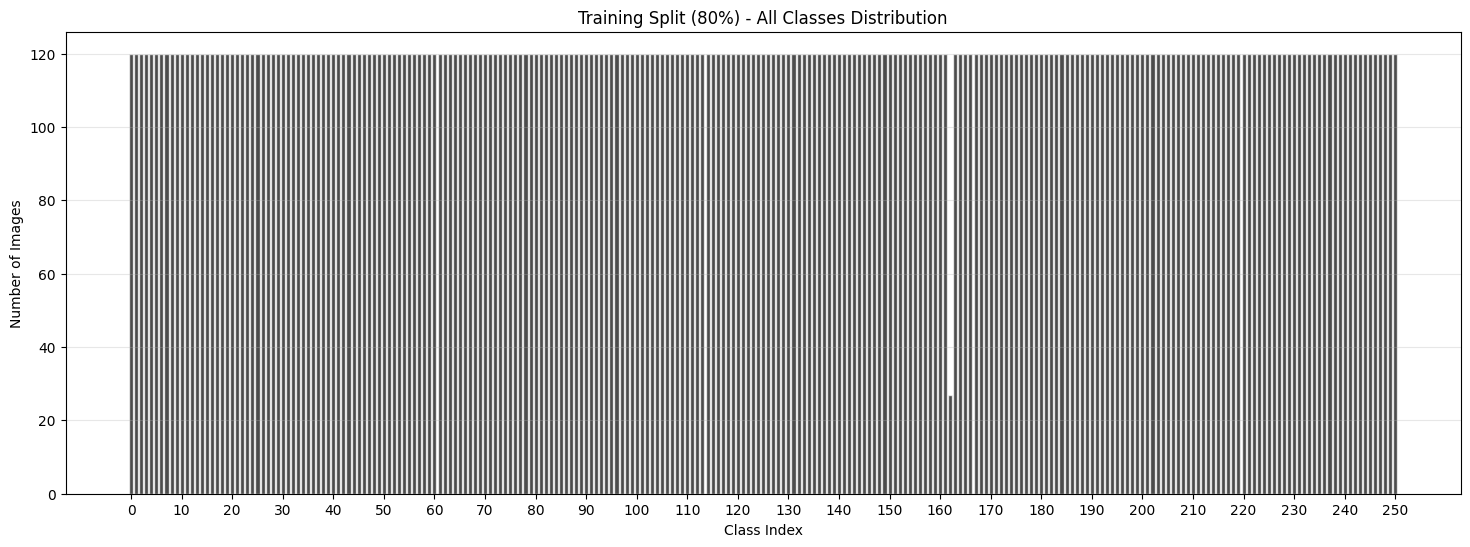

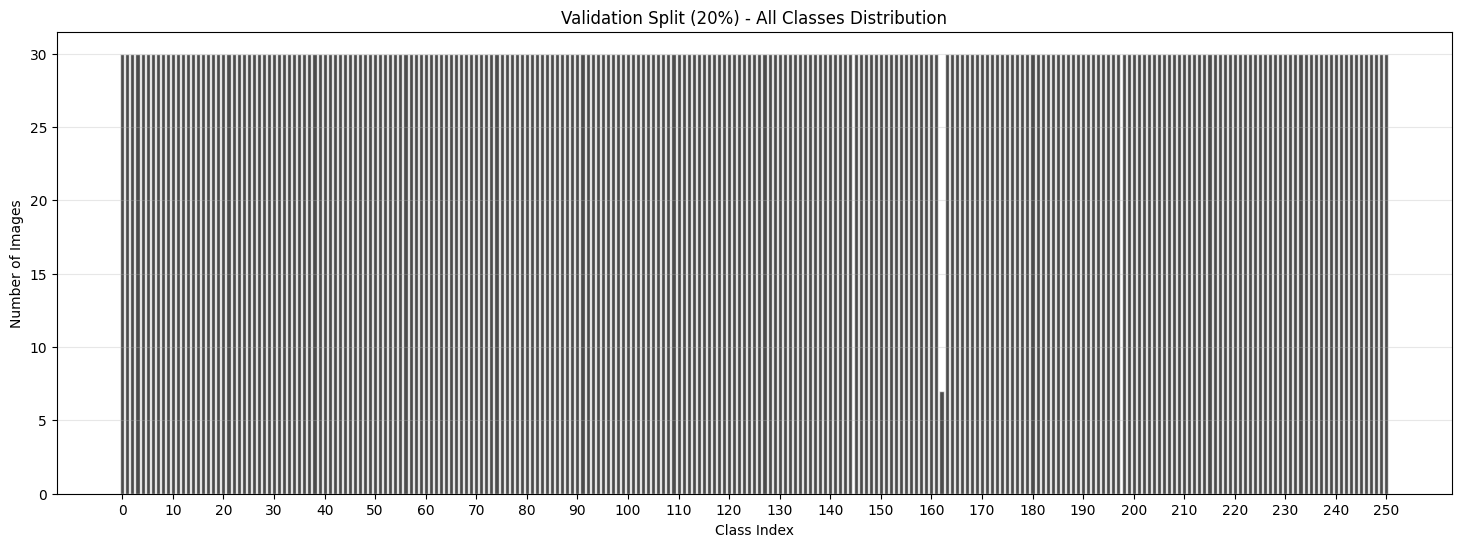

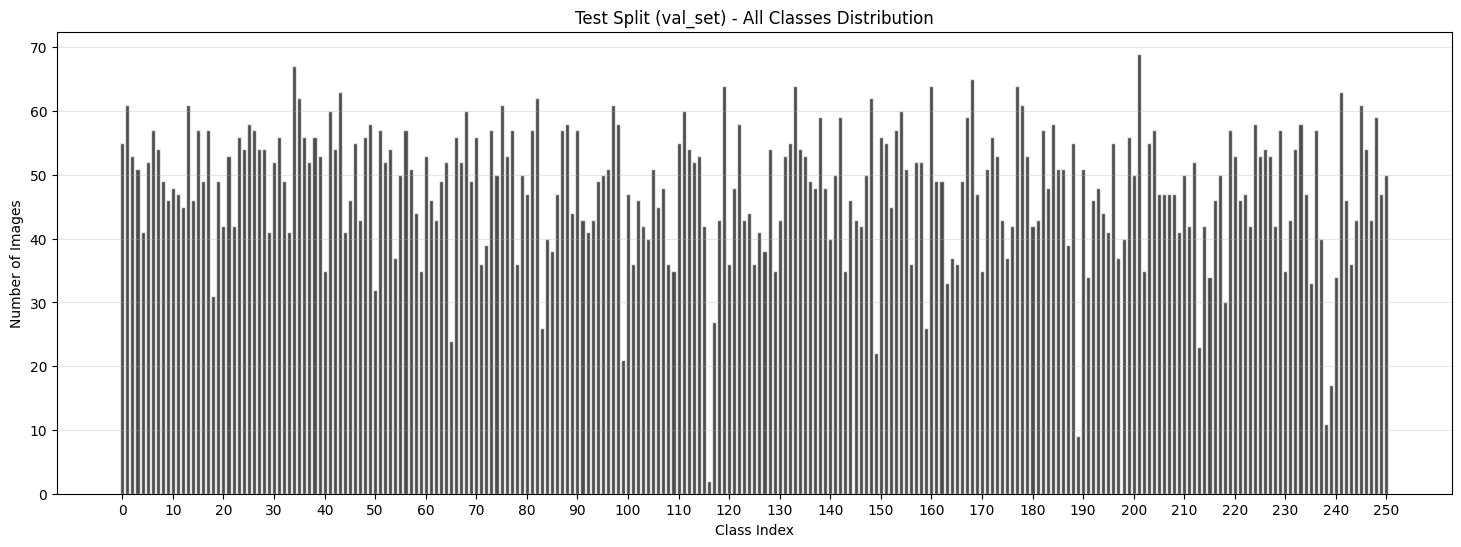

In [ ]:
# Data Analysis and Visualization for custom splits
def analyze_dataset(df, title):
    """Analyze class distribution in dataset"""
    plt.figure(figsize=(18, 6))

    # Class distribution - show all classes
    class_counts = df['label'].value_counts().sort_index()

    # Create bar chart for all classes
    plt.bar(range(len(class_counts)), class_counts.values, alpha=0.7, color='black', edgecolor='white')
    plt.title(f'{title} - All Classes Distribution')
    plt.xlabel('Class Index')
    tick_indices = range(0, len(class_counts), 10)
    plt.xticks(tick_indices, class_counts.index[tick_indices])

    plt.ylabel('Number of Images')
    plt.grid(True, alpha=0.3, axis='y')


analyze_dataset(train_df, "Training Split (80%)")
analyze_dataset(val_df, "Validation Split (20%)")
analyze_dataset(test_df, "Test Split (val_set)")

## Building the supervised model
The supervised model was built as an expanding path, batch normalization is added between each convolution layer and activation layer for stability, maxpooling is applied after every activation to keep only relevant information. The expanding path finishes with a Global Average Pooling to extract the most relevant information into an efficient manner, a Dense layer to combine the information together, a Dropout to prevent overfitting and a last Dense layer to output the predicted classes.

In [ ]:
# CNN model
def CostumCNN(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes = NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(64, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    # Block 4

    x = layers.Conv2D(512, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    # Output layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
model = CostumCNN(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=NUM_CLASSES)
param_counts = model.count_params()
print(f"Number of parameters in the model: {param_counts}")
print(f'Memory estimate: ~{param_counts * 4 / 1024 / 1024:.1f} MB')

Number of parameters in the model: 2337403
Memory estimate: ~8.9 MB


## Setting the hyperparameters and training the model
The learning rate is dynamic by using the `tf.keras.optimizers.schedules.ExponentialDecay` scheduler, the optimizer used is `tf.keras.optimizers.Adam`, `tf.keras.callbacks.EarlyStopping` early stopping is implemented monitoring
validation loss to prevent overfitting.

In [ ]:
lr = 1e-3
scheduler = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=lr,
    decay_steps=800,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=scheduler)

earlystopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

In [ ]:
start = time.time()
history_attention = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[earlystopping, checkpoint]
)
end = time.time()
time_sup = end - start
print(f"Training time: {time_sup} seconds")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 162s 514ms/step - accuracy: 0.0119 - loss: 5.4802 - top_5_accuracy: 0.0478 - val_accuracy: 0.0040 - val_loss: 6.0370 - val_top_5_accuracy: 0.0238
Epoch 2/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 140s 465ms/step - accuracy: 0.0307 - loss: 5.0341 - top_5_accuracy: 0.1148 - val_accuracy: 0.0196 - val_loss: 5.2681 - val_top_5_accuracy: 0.0801
Epoch 3/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 140s 464ms/step - accuracy: 0.0458 - loss: 4.8504 - top_5_accuracy: 0.1549 - val_accuracy: 0.0433 - val_loss: 4.8955 - val_top_5_accuracy: 0.1499
Epoch 4/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 143s 475ms/step - accuracy: 0.0529 - loss: 4.7311 - top_5_accuracy: 0.1825 - val_accuracy: 0.0528 - val_loss: 4.7831 - val_top_5_accuracy: 0.1753
Epoch 5/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 199s 464ms/step - accuracy: 0.0640 - loss: 4.6443 - top_5_accuracy: 0.2050 - val_accuracy: 0.0714 - val_loss: 4.6619 - val_top_5_accuracy: 0.2111
Epoch 6/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 140s 465ms/step - accuracy: 0.

### Visualizing training history

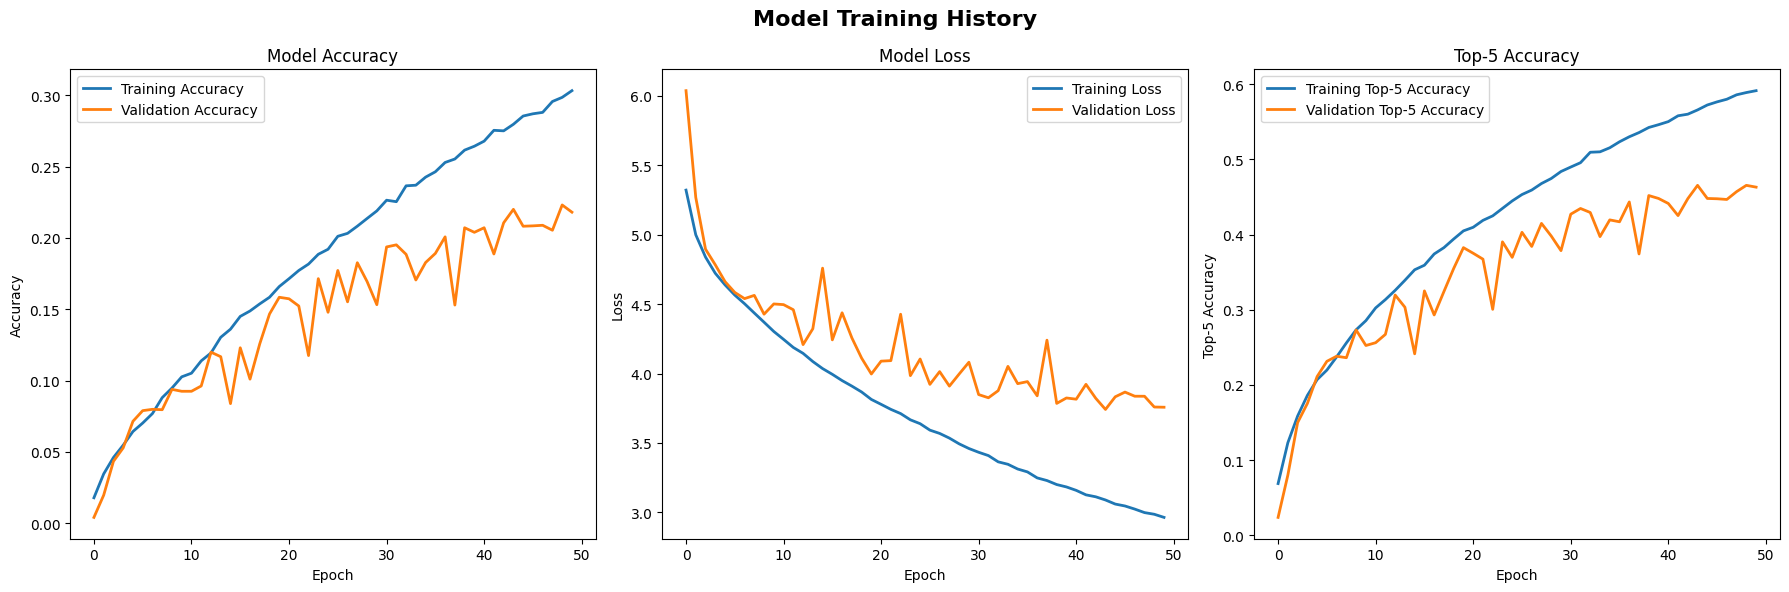

In [ ]:
# Training history visualization
def training_history(history, title="Model Training History"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot training & validation accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Plot training & validation loss
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    axes[2].plot(history.history['top_5_accuracy'], label='Training Top-5 Accuracy', linewidth=2)
    axes[2].plot(history.history['val_top_5_accuracy'], label='Validation Top-5 Accuracy', linewidth=2)
    axes[2].set_title('Top-5 Accuracy')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Top-5 Accuracy')
    axes[2].legend()


    plt.suptitle(f'{title}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

training_history(history_attention, title="Model Training History")

### Saving the model to use it later for evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd '/content/drive/MyDrive/Colab Notebooks/ProgettiEsami/ProjectSupervised'

/content/drive/.shortcut-targets-by-id/18ApmfjYWD4jvKN1nC73EWKyXtHUj728u/ProjectSupervised


In [ ]:
model.save('./best_model.keras')